# 🧠 Emotion Detection from Text — End-to-End NLP Pipeline

> **Goal:** Classify free-form text into 6 emotion categories: *Joy, Sadness, Anger, Fear, Love, Surprise*.

This notebook follows the complete ML workflow:
1. Data Ingestion & EDA
2. Classical ML (TF-IDF + Sklearn)
3. Deep Learning (RNN / LSTM / GRU)
4. Transformer Fine-Tuning (DistilBERT)


---

## 📦 Step 1: Imports & Setup

In [51]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from wordcloud import WordCloud
import re
import string
import emoji
import nltk
from sklearn.preprocessing import StandardScaler
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
nltk.download('stopwords')
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import tensorflow
from tensorflow import keras
from keras.layers import Input, Dense, SimpleRNN, LSTM, GRU, Embedding, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import precision_recall_fscore_support

[nltk_data] Downloading package stopwords to C:\Users\Sagar
[nltk_data]     Singh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---

## 📥 Step 2: Data Acquisition

### 2.1 Download Dataset via Kaggle API

In [34]:
# Downloading the datset using kaggle API
! kaggle datasets download praveengovi/emotions-dataset-for-nlp

Dataset URL: https://www.kaggle.com/datasets/praveengovi/emotions-dataset-for-nlp
License(s): CC-BY-SA-4.0
emotions-dataset-for-nlp.zip: Skipping, found more recently modified local copy (use --force to force download)


### 2.2 Extract Dataset ZIP

In [2]:
# Extracting the Dataset
import zipfile
with zipfile.ZipFile('emotions-dataset-for-nlp.zip', 'r') as zip_ref:
    zip_ref.extractall('')

### 2.3 Load Splits into DataFrames

In [2]:
# Importing the text as dataframe

train_df = pd.read_csv('train.txt', sep=';', names=['text', 'emotion'])
test_df = pd.read_csv('test.txt', sep=';', names=['text', 'emotion'])
val_df = pd.read_csv('val.txt', sep=';', names=['text', 'emotion'])


print(f'The shape of train_df is {train_df.shape}')
print(f'The shape of test_df is {test_df.shape}')
print(f'The shape of val_df is {val_df.shape}')

The shape of train_df is (16000, 2)
The shape of test_df is (2000, 2)
The shape of val_df is (2000, 2)


## Basic Dataset inspection

### 3.1 Training Set — First 5 Rows

In [3]:
# first 5 rows of training dataset

train_df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


### 3.2 Test Set — First 5 Rows

In [4]:
# first 5 rows of testing dataset

test_df.head()

,text,emotion
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


### 3.3 Validation Set — First 5 Rows

In [5]:
# first 5 rows of valuation dataset

val_df.head()

,text,emotion
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


### 3.4 Schema & Data Types (`.info()`)

In [6]:
# Checking the summary of the training dataset

train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     16000 non-null  object
 1   emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


### Insights:

- The Dtype of columns is object making it sitable for NLP related tasks.
- The dataset doesn't contain any null values.

### 3.5 Statistical Summary (`.describe()`)

In [7]:
# Checking the statistcal summary of training dataset

train_df.describe()

,text,emotion
count,16000,16000
unique,15969,6
top,i feel on the verge of tears from weariness i ...,joy
freq,2,5362


### Insights:

- The dataset has 15,969 unique text entries out of 16,000 records, indicating very low duplication and a diverse range of emotional expressions.
- There are 6 emotion categories, with joy being the most frequent class (5,362 samples), suggesting a class imbalance that may affect model performance if not handled properly.

## Data Quality Check

### 4.1 Null Value Check

In [8]:
# Checking the null values

train_df.isnull().sum()

text       0
emotion    0
dtype: int64

### Insights:

- The dataset doesn't contains any null value

### 4.2 Duplicate Row Check

In [9]:
# Checking for duplicates
train_df.duplicated().sum()

np.int64(1)

### Insights:

- Only 1 duplicate row found 
- But when we are checked the statistcal summary of the training dataset then we know that we have 15,969 unique text for the text column so we have to deal with that also.

### 4.3 Conflicting Label Duplicates

In [10]:
# Checking the duplicates in text column

train_df[train_df.duplicated(subset='text',keep=False)].sort_values(by='text')

,text,emotion
8246,i am not amazing or great at photography but i...,love
3508,i am not amazing or great at photography but i...,joy
15705,i began to feel accepted by gaia on her own terms,joy
5277,i began to feel accepted by gaia on her own terms,love
8804,i bet taylor swift basks in the knowledge that...,fear
...,...,...
11354,i write these words i feel sweet baby kicks fr...,love
7685,im still not sure why reilly feels the need to...,surprise
2908,im still not sure why reilly feels the need to...,fear
9596,ive also made it with both sugar measurements ...,joy


### Insights:

- The dataset contains duplicate text samples mapped to different emotion labels, indicating label inconsistency/noise in the dataset.
- Around 62 duplicated text entries were found, which may confuse the model during training and should be cleaned or resolved before building the emotion classification model.

### 4.4 Remove Conflicting Duplicates

In [11]:
# Removing the duplicates by text column

train_df.drop_duplicates(subset='text', keep = False, inplace=True)

### 4.5 Dataset Shape After Deduplication

In [12]:
# Checking the new shape of training dataset

print("The shape of training dataset is", train_df.shape)

The shape of training dataset is (15938, 2)


## Target Variable Analysis

### 5.1 Class Value Counts

In [14]:
# Checking the distribution of target variable in the training dataset
train_df["emotion"].value_counts()

emotion
joy         5344
sadness     4662
anger       2152
fear        1926
love        1289
surprise     565
Name: count, dtype: int64

### 5.2 Class Distribution Plot

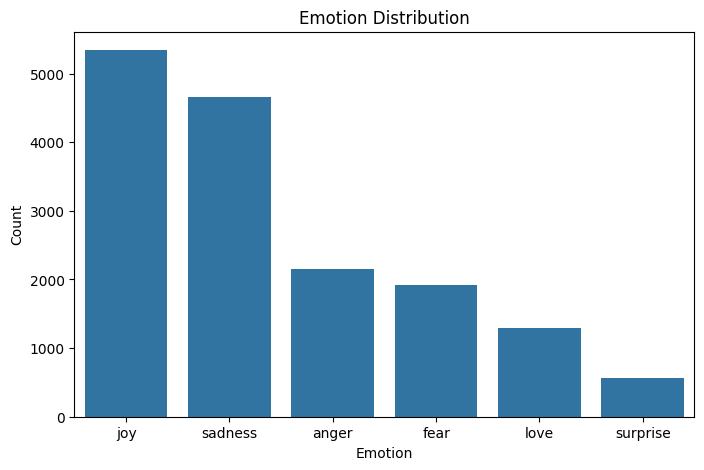

In [15]:
# Plotting the distribution of target variables
plt.figure(figsize=(8,5))
sns.countplot(x=train_df["emotion"], order=train_df["emotion"].value_counts().index)
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

### Insights:

- The dataset is imbalanced, with joy and sadness dominating the samples, while surprise has significantly fewer instances, which may lead to biased model predictions toward majority classes.
- Handling class imbalance using techniques such as class weights, oversampling, or data augmentation can help improve performance on minority emotions like love and surprise.

### 5.3 Test Set Class Counts

In [16]:
# Checking the classes of target variable in the testing dataset
test_df["emotion"].value_counts()

emotion
joy         695
sadness     581
anger       275
fear        224
love        159
surprise     66
Name: count, dtype: int64

### 5.4 Validation Set Class Counts

In [17]:
# Checking the classes of target variable in the valuation dataset
val_df["emotion"].value_counts()

emotion
joy         704
sadness     550
anger       275
fear        212
love        178
surprise     81
Name: count, dtype: int64

### Insights:

- Target variable classes is same for all the dataset.

## Text Feature Engineering

### 6.1 Character Count & Word Count Features — Training Set

In [18]:
# Training Dataset
# Character Count

train_df["char_count"] = train_df["text"].apply(len)

# word Count

train_df['word_count'] = train_df['text'].apply(lambda x:len(x.split()))

# Sentence Count

train_df['sent_count'] = train_df['text'].apply(lambda x:len(x.split('.')))

### 6.2 Character Count & Word Count Features — Test Set

In [19]:
# Testing Dataset
# Character Count

test_df["char_count"] = test_df["text"].apply(len)

# word Count

test_df['word_count'] = test_df['text'].apply(lambda x:len(x.split()))

# Sentence Count

test_df['sent_count'] = test_df['text'].apply(lambda x:len(x.split('.')))

### 6.3 Character Count & Word Count Features — Validation Set

In [20]:
# Valuation Dataset
# Character Count

val_df["char_count"] = val_df["text"].apply(len)

# word Count

val_df['word_count'] = val_df['text'].apply(lambda x:len(x.split()))

# Sentence Count

val_df['sent_count'] = val_df['text'].apply(lambda x:len(x.split('.')))

### 6.4 Statistical Summary of Text-Length Features

In [21]:
# Statistcal summary of these new features

train_df[
    ["char_count", "word_count", "sent_count"]
].describe()

,char_count,word_count,sent_count
count,15938.000000,15938.000000,15938.0
mean,96.902811,19.177124,1.0
std,55.948933,10.994831,0.0
min,7.000000,2.000000,1.0
25%,53.000000,11.000000,1.0
50%,86.000000,17.000000,1.0
75%,129.000000,25.000000,1.0
max,300.000000,66.000000,1.0


### Insights:

- The text samples contain an average of 19 words and 97 characters, indicating that most entries are short sentences suitable for emotion classification tasks.
- The sent_count column has no variation (all values are 1), meaning every sample contains a single sentence.

### 6.5 Word Count Distribution Plot

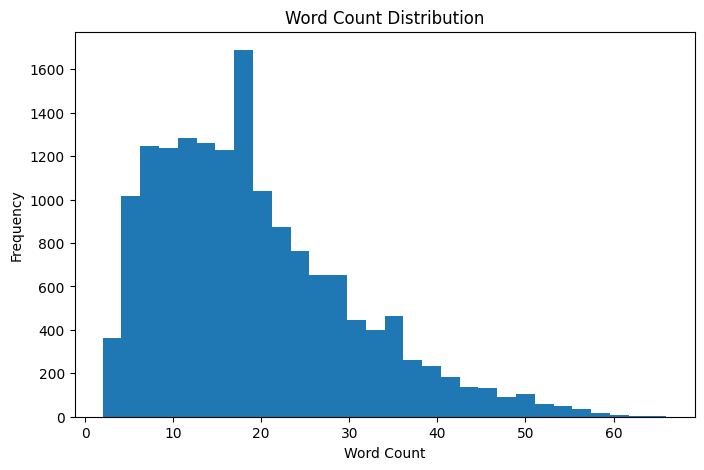

In [59]:
# Word Count Distribution

plt.figure(figsize=(8,5))

plt.hist(train_df["word_count"], bins=30)

plt.title("Word Count Distribution")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.show()

### 6.6 Character Count Distribution Plot

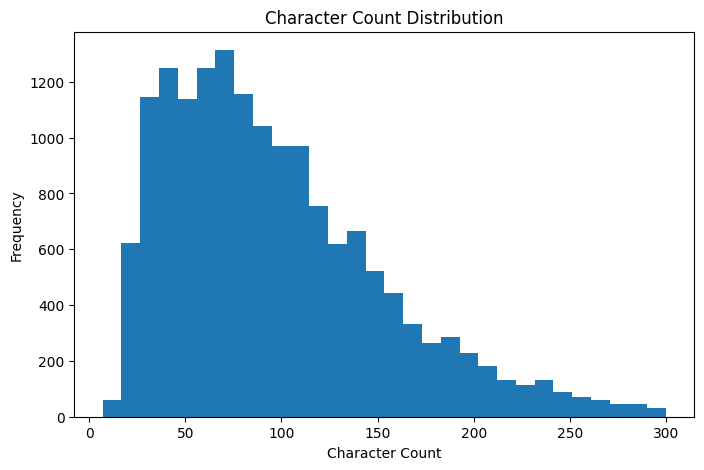

In [60]:
# Character Count Distribution

plt.figure(figsize=(8,5))

plt.hist(
    train_df['char_count'],
    bins=30
)

plt.title("Character Count Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")

plt.show()

### Insights:

- Both word_count and char_count distributions are positively skewed, showing that most text samples are short while a small number of samples are significantly longer.

### 6.7 Average Word Count per Emotion

In [62]:
# Average word count per emotion

train_df.groupby("emotion")['word_count'].mean()

emotion
anger       19.228160
fear        18.870197
joy         19.508234
love        20.737005
sadness     18.361218
surprise    20.070796
Name: word_count, dtype: float64

### 6.8 Average Word Count per Emotion — Bar Plot

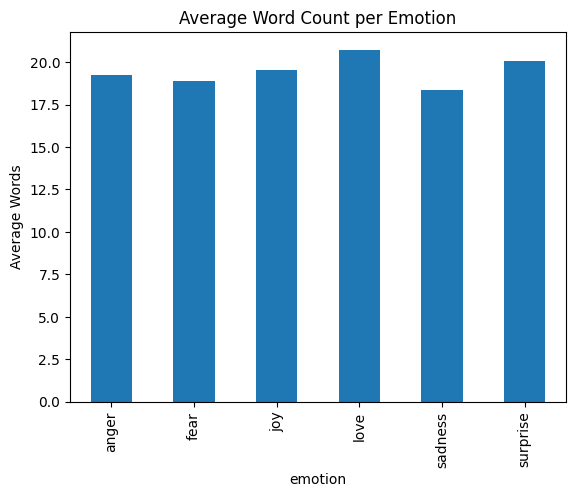

In [26]:
# Plot of Average word count per emotion
train_df.groupby("emotion")["word_count"].mean().plot(
    kind="bar"
)

plt.title("Average Word Count per Emotion")
plt.ylabel("Average Words")

plt.show()

### Insights:

- The average word count is fairly similar across all emotion classes, ranging from approximately 18 to 21 words, indicating that text length alone may not strongly differentiate emotions.
- love and surprise tend to have slightly longer texts on average, while sadness has the shortest average word count among all emotion categories.

### 6.9 Overall Word Cloud

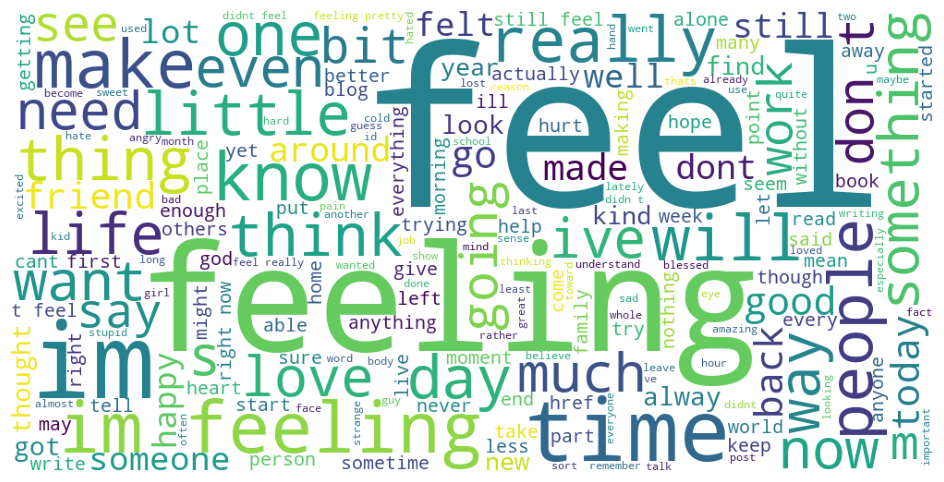

In [27]:
# Word cloud

all_text = " ".join(train_df["text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

### Insights:

- The word cloud shows that terms like “feel”, “feeling”, “time”, “people”, and “know” appear most frequently, indicating that the dataset strongly revolves around personal experiences, emotions, and self-expression.
- Many common emotional-expression words dominate the corpus, suggesting that additional preprocessing such as stopword removal or lemmatization may help highlight more emotion-specific keywords for better model learning.

### 6.10 Emotion-Specific Word Clouds

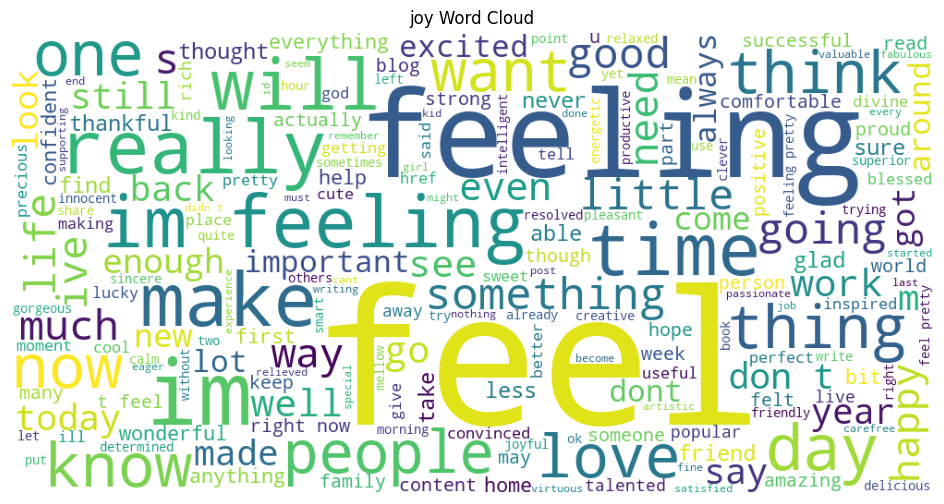

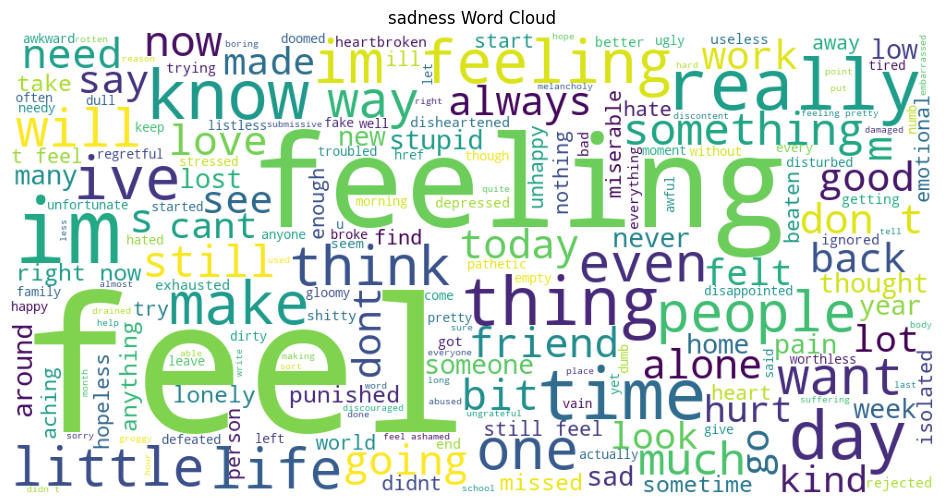

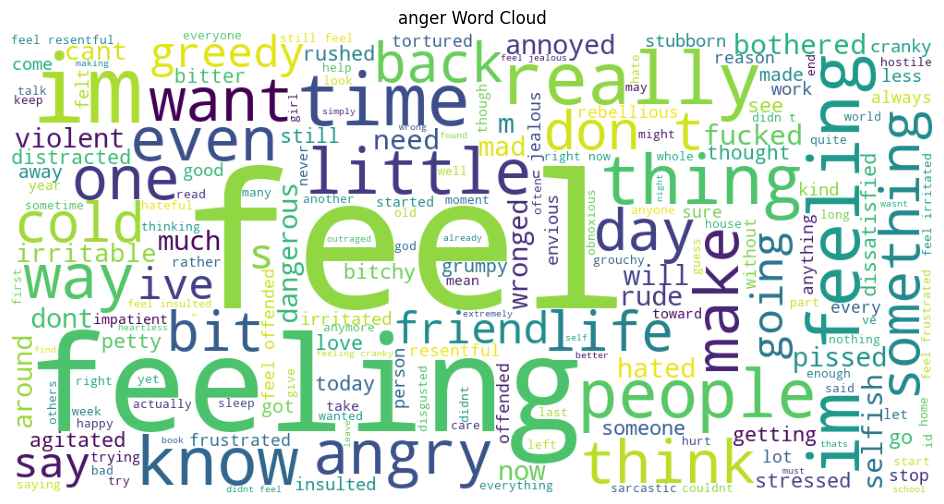

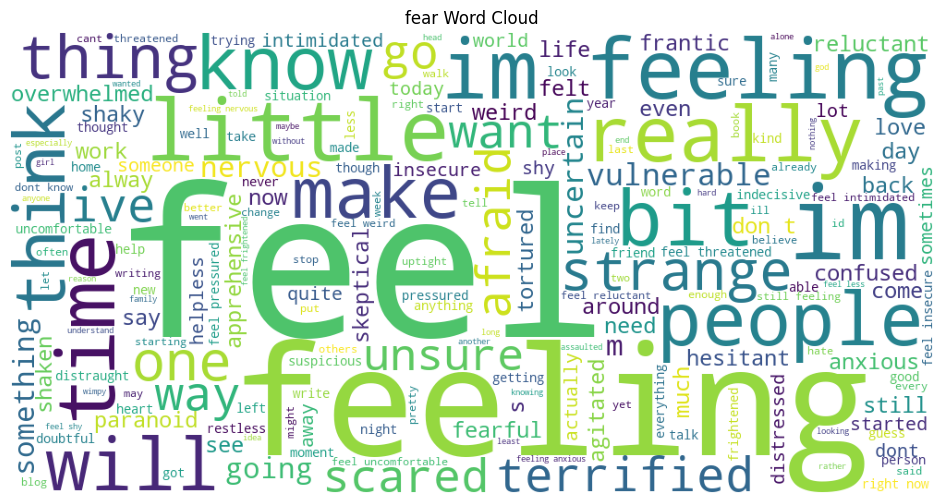

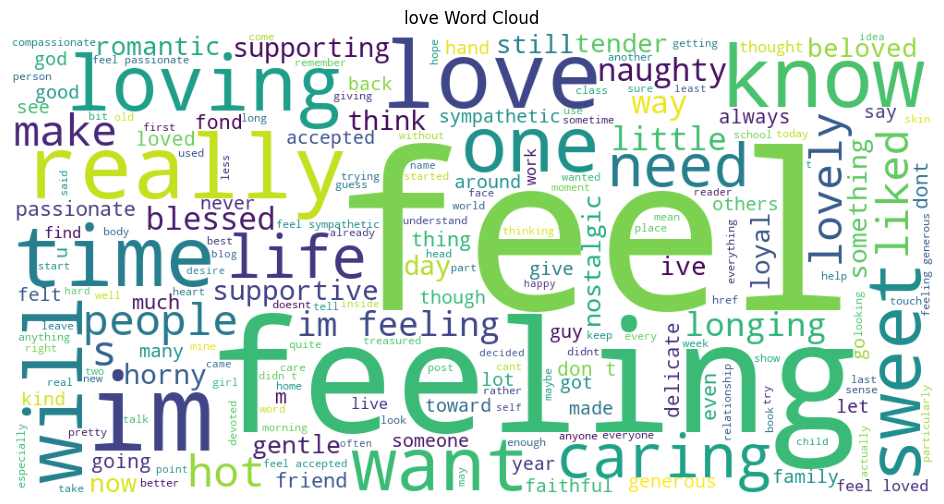

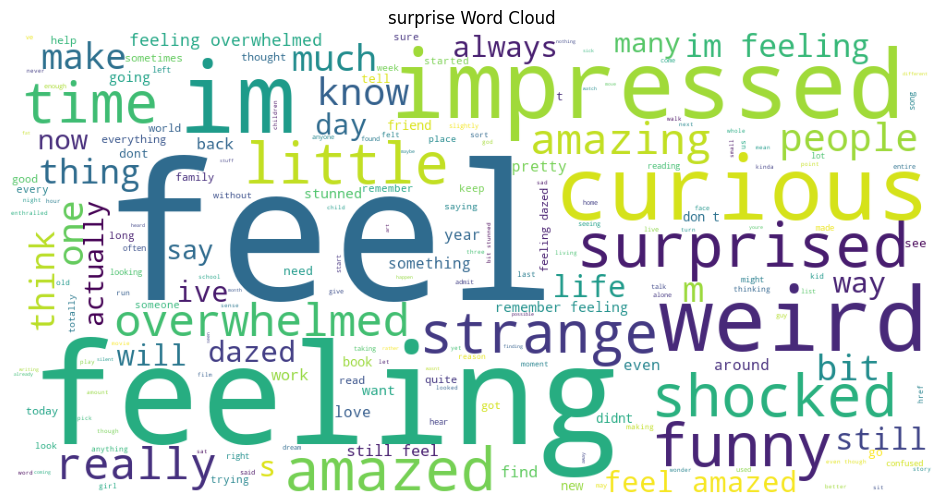

In [29]:
# Emotion specific word cloud

for i in train_df['emotion'].value_counts().index:
    text = " ".join(
        train_df[train_df["emotion"]==i]["text"]
    )

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(12,6))

    plt.imshow(wordcloud)

    plt.axis("off")

    plt.title(f"{i} Word Cloud")

    plt.show()

### Insights:

- The emotions specific word cloud is dominated by words such as “feel”, “feeling”.
- There emotion specific keywords also exists like 'lovely' for love, 'amazed' for  suprise, 'afraid' from fear, etc.

### 6.11 Outlier Check — Longest Texts

In [30]:
# Checking for outliers in terms of text length

train_df.sort_values(
    by="word_count",
    ascending=False
).head()

,text,emotion,char_count,word_count
6322,i guess which meant or so i assume no photos n...,sadness,291,66
7222,i am happier this year in all ways i am just g...,joy,291,64
9626,i feel in my bones like nobody cares if im her...,sadness,281,64
9618,i feel you i dont believ in you but i keep my ...,joy,296,64
46,i lost my special mind but don t worry i m sti...,joy,289,64


### Insights:

- Although the average text length is around 19 words, the dataset also contains a small number of longer samples reaching up to 66 words, indicating a right-skewed distribution of text lengths.
- These longer texts are not extreme enough to be considered harmful outliers and may actually provide richer emotional context, making them potentially valuable for emotion classification models.

### 6.12 Vocabulary Size Analysis

In [31]:
# Vocabulary Analysis

vocab = set()

for text in train_df["text"]:
    for word in text.split():
        vocab.add(word)

print("Vocabulary Size:", len(vocab))

Vocabulary Size: 15197


### Insights:

- The dataset contains a vocabulary size of 15,197 unique words, indicating rich linguistic diversity and a wide range of emotional expressions in the text corpus.
- A large vocabulary can help the model capture nuanced emotional patterns, but it may also introduce sparse or low-frequency words, making preprocessing steps like stopword removal, stemming, or lemmatization beneficial.

# Observations/Insights after EDA

- The dataset contains 15,938 text samples across 6 emotion categories after removing duplicate/conflicting entries, with no missing values detected.

- The class distribution is moderately imbalanced, where joy and sadness contain significantly more samples compared to surprise and fear.

- Most text samples are short and concise, with an average length of approximately 19 words and 97 characters.

- Text length distributions are positively skewed, but no severe outliers were observed, making the dataset manageable for sequence-based deep learning models.

- The sentence count feature showed almost no variance because most samples consist of a single sentence; therefore, it is unlikely to contribute meaningful information during modeling.

- Duplicate texts with conflicting emotion labels were identified during EDA, indicating minor annotation inconsistencies/noise within the dataset. Such samples were removed to ensure cleaner supervision for model training.

- The dataset contains a vocabulary of approximately 15,197 unique words before preprocessing, demonstrating diverse linguistic patterns and emotional expressions.

- Word cloud analysis revealed distinct vocabulary usage across different emotions, suggesting that textual patterns are strongly associated with emotion classes.

- Since the majority of samples are relatively short, a sequence length (maxlen) around 64 tokens is expected to sufficiently capture most contextual information during padding.

- For deep learning approaches such as LSTM/RNN, lightweight preprocessing (lowercasing, tokenization, padding) is preferable over aggressive preprocessing techniques like stemming or extensive stopword removal, as preserving contextual information is important for sequence modeling.

---

## 🤖 Phase 1: Classical Machine Learning (TF-IDF + Sklearn)

> In this phase we apply aggressive NLP preprocessing (stemming, stopword removal) suited for TF-IDF bag-of-words features, then benchmark 10 classifiers.


### 7.1 Text Preprocessing for ML Pipeline (Stemming + Stopword Removal)

In [63]:
# NLP TEXT PREPROCESSING FOR ML PIPELINE

# INITIALIZE OBJECTS

stop_words = set(stopwords.words('english'))
negation_words = {'not', 'no', 'nor', 'never'}
stop_words = stop_words - negation_words

stemmer = PorterStemmer()

# CHAT WORD DICTIONARY
chat_words = {
    "u": "you",
    "ur": "your",
    "idk": "i do not know",
    "omg": "oh my god",
    "btw": "by the way",
    "lol": "laugh",
    "thx": "thanks",
    "pls": "please"
}

# CHAT WORD CONVERSION FUNCTION
def chat_conversion(text):

    new_text = []

    for word in text.split():

        if word in chat_words:
            new_text.append(chat_words[word])

        else:
            new_text.append(word)

    return " ".join(new_text)

# MAIN CLEANING FUNCTION
def clean_text(text):

    # LOWERCASE
    text = text.lower()

    # REMOVE HTML TAGS
    text = re.sub(r'<.*?>', '', text)

    # REMOVE URLS
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # CHAT WORD TREATMENT
    text = chat_conversion(text)

    # HANDLE EMOJIS
    text = emoji.demojize(text)

    # Remove colon from emoji text
    text = text.replace(":", " ")

    # REMOVE PUNCTUATIONS

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # REMOVE NUMBERS
    text = re.sub(r'\d+', '', text)

    # TOKENIZATION
    words = text.split()

    # STOPWORD REMOVAL
    words = [
        word for word in words
        if word not in stop_words
    ]

    # STEMMING
    words = [
        stemmer.stem(word)
        for word in words
    ]

    # JOIN WORDS
    text = " ".join(words)

    # REMOVE EXTRA SPACES
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# APPLY PREPROCESSING
ml_train = train_df.copy()
ml_test = test_df.copy()
ml_val = val_df.copy()

ml_train["clean_text"] = ml_train["text"].apply(clean_text)

ml_test["clean_text"] = ml_test["text"].apply(clean_text)

ml_val["clean_text"] = ml_val["text"].apply(clean_text)


# CHECK RESULTS
ml_train[["text", "clean_text"]].head()

,text,clean_text
0,i didnt feel humiliated,didnt feel humili
1,i can go from feeling so hopeless to so damned...,go feel hopeless damn hope around someon care ...
2,im grabbing a minute to post i feel greedy wrong,im grab minut post feel greedi wrong
3,i am ever feeling nostalgic about the fireplac...,ever feel nostalg fireplac know still properti
4,i am feeling grouchy,feel grouchi


### 7.2 Label Encoding

In [64]:
# Label Encoding

encoder = LabelEncoder()

y_train = encoder.fit_transform(
    ml_train["emotion"]
)

y_test = encoder.transform(
    ml_test["emotion"]
)

y_val = encoder.transform(
    ml_val["emotion"]
)

### 7.3 TF-IDF Vectorization

In [65]:
# TF-IDF

tfidf = TfidfVectorizer(
    max_features=5000
)

X_train = tfidf.fit_transform(
    ml_train["clean_text"]
)

X_test = tfidf.transform(
    ml_test["clean_text"]
)

X_val = tfidf.transform(
    ml_val["clean_text"]
)

### 7.4 Baseline Model — Logistic Regression (Quick Check)

              precision    recall  f1-score   support

           0       0.85      0.79      0.82       275
           1       0.86      0.79      0.83       224
           2       0.83      0.94      0.88       695
           3       0.78      0.55      0.64       159
           4       0.87      0.91      0.89       581
           5       0.85      0.50      0.63        66

    accuracy                           0.85      2000
   macro avg       0.84      0.74      0.78      2000
weighted avg       0.85      0.85      0.84      2000



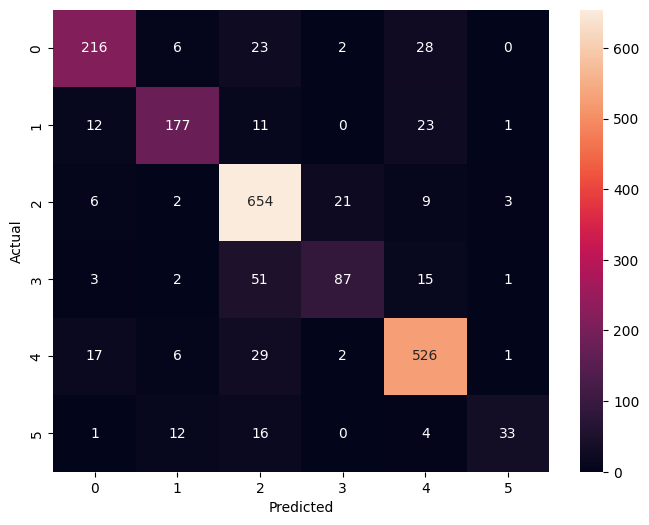

In [66]:
# Baseline Model
Baseline_model = LogisticRegression()

Baseline_model.fit(X_train, y_train)

# prediction
y_pred = Baseline_model.predict(X_test)

print(classification_report(
    y_test,
    y_pred
))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 7.5 Evaluation Helper Function

In [67]:
# Evaluation Function

training_accuracy_scores = []
testing_accuracy_scores = []

training_precision_scores = []
testing_precision_scores = []

training_recall_scores = []
testing_recall_scores = []

training_f1_scores = []
testing_f1_scores = []

model_names = []

def evaluate_model_performance(
    model,
    x_train,
    y_train,
    x_test,
    y_test
):

    # TRAIN MODEL
    model.fit(x_train, y_train)

    # PREDICTIONS
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # ACCURACY
    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    ) * 100

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    ) * 100

    # PRECISION
    train_precision = precision_score(
        y_train,
        y_train_pred,
        average='weighted'
    )

    test_precision = precision_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    # RECALL
    train_recall = recall_score(
        y_train,
        y_train_pred,
        average='weighted'
    )

    test_recall = recall_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    # F1 SCORE
    train_f1 = f1_score(
        y_train,
        y_train_pred,
        average='weighted'
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    # STORE RESULTS
    model_names.append(model.__class__.__name__)

    training_accuracy_scores.append(train_accuracy)
    testing_accuracy_scores.append(test_accuracy)

    training_precision_scores.append(train_precision)
    testing_precision_scores.append(test_precision)

    training_recall_scores.append(train_recall)
    testing_recall_scores.append(test_recall)

    training_f1_scores.append(train_f1)
    testing_f1_scores.append(test_f1)

    # DISPLAY RESULTS
    print("=" * 60)
    print(f"{model.__class__.__name__} PERFORMANCE")
    print("=" * 60)

    print("\nTRAINING METRICS")
    print("-" * 30)

    print(f"Accuracy : {train_accuracy:.2f}%")
    print(f"Precision: {train_precision:.4f}")
    print(f"Recall   : {train_recall:.4f}")
    print(f"F1 Score : {train_f1:.4f}")

    print("\nTESTING METRICS")
    print("-" * 30)

    print(f"Accuracy : {test_accuracy:.2f}%")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall   : {test_recall:.4f}")
    print(f"F1 Score : {test_f1:.4f}")

    # CONFUSION MATRIX
    cm = confusion_matrix(
        y_test,
        y_test_pred
    )
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )
    plt.title(
        f"{model.__class__.__name__} Confusion Matrix"
    )

    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")

    plt.show()

    # CLASSIFICATION REPORT
    print("\nCLASSIFICATION REPORT")
    print("-" * 30)

    print(
        classification_report(
            y_test,
            y_test_pred
        )
    )

    print("\n")

### 7.6 Logistic Regression

LogisticRegression PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 91.23%
Precision: 0.9229
Recall   : 0.9123
F1 Score : 0.9141

TESTING METRICS
------------------------------
Accuracy : 84.60%
Precision: 0.8655
Recall   : 0.8460
F1 Score : 0.8511


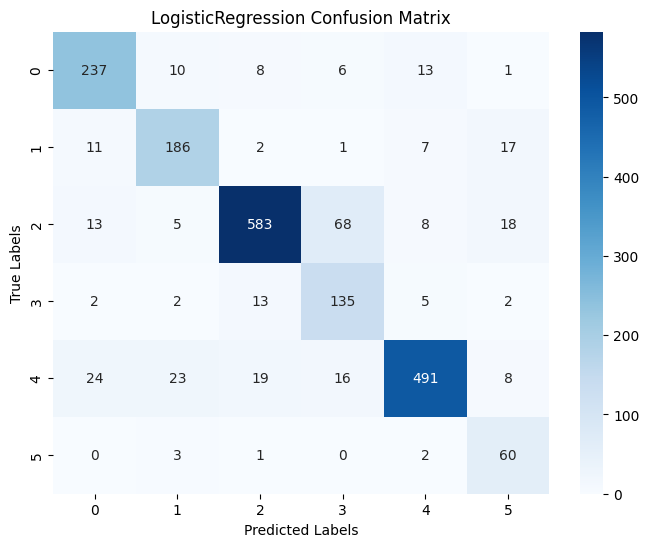


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       275
           1       0.81      0.83      0.82       224
           2       0.93      0.84      0.88       695
           3       0.60      0.85      0.70       159
           4       0.93      0.85      0.89       581
           5       0.57      0.91      0.70        66

    accuracy                           0.85      2000
   macro avg       0.78      0.86      0.81      2000
weighted avg       0.87      0.85      0.85      2000





In [68]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

evaluate_model_performance(
    lr_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.7 Linear SVC

LinearSVC PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 96.36%
Precision: 0.9646
Recall   : 0.9636
F1 Score : 0.9638

TESTING METRICS
------------------------------
Accuracy : 85.85%
Precision: 0.8649
Recall   : 0.8585
F1 Score : 0.8607


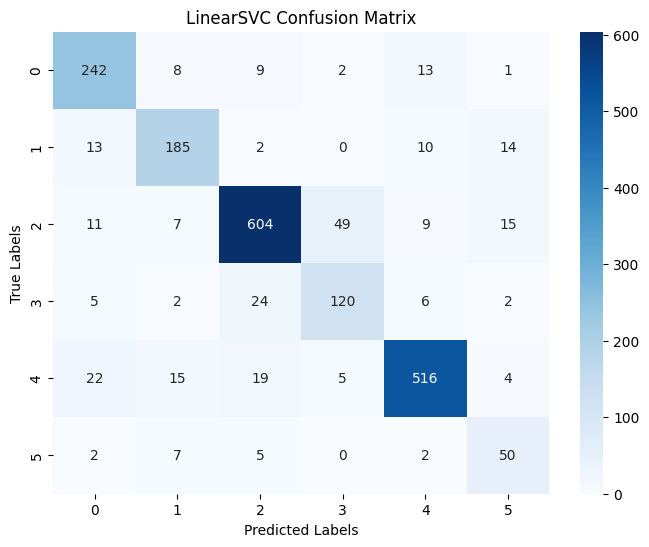


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       275
           1       0.83      0.83      0.83       224
           2       0.91      0.87      0.89       695
           3       0.68      0.75      0.72       159
           4       0.93      0.89      0.91       581
           5       0.58      0.76      0.66        66

    accuracy                           0.86      2000
   macro avg       0.79      0.83      0.81      2000
weighted avg       0.86      0.86      0.86      2000





In [69]:
svm_model = LinearSVC(
    class_weight='balanced'
)

evaluate_model_performance(
    svm_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.8 Decision Tree Classifier

DecisionTreeClassifier PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 99.95%
Precision: 0.9995
Recall   : 0.9995
F1 Score : 0.9995

TESTING METRICS
------------------------------
Accuracy : 78.75%
Precision: 0.8038
Recall   : 0.7875
F1 Score : 0.7925


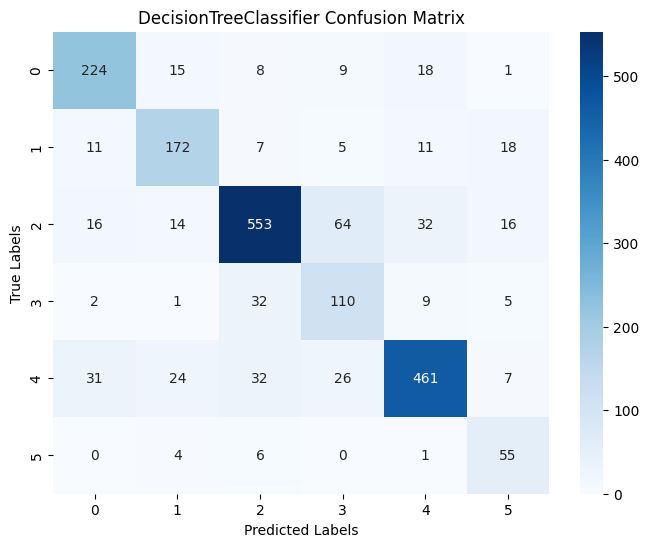


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       275
           1       0.75      0.77      0.76       224
           2       0.87      0.80      0.83       695
           3       0.51      0.69      0.59       159
           4       0.87      0.79      0.83       581
           5       0.54      0.83      0.65        66

    accuracy                           0.79      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.80      0.79      0.79      2000





In [70]:
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

evaluate_model_performance(
    dt_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.9 Random Forest Classifier

RandomForestClassifier PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 99.95%
Precision: 0.9995
Recall   : 0.9995
F1 Score : 0.9995

TESTING METRICS
------------------------------
Accuracy : 83.70%
Precision: 0.8488
Recall   : 0.8370
F1 Score : 0.8404


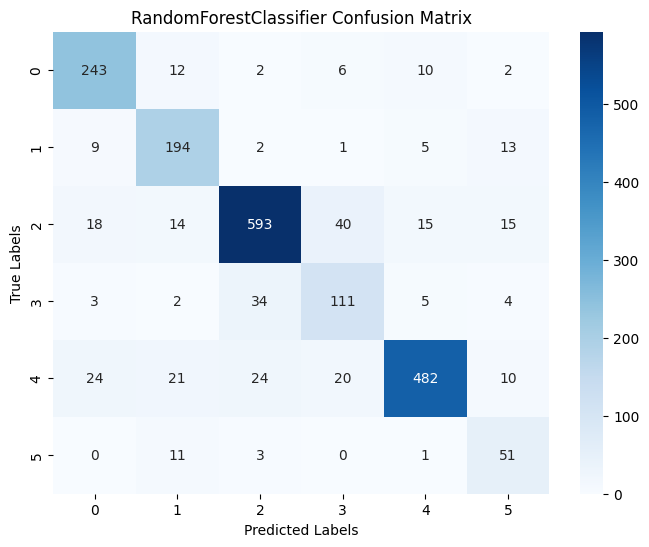


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       275
           1       0.76      0.87      0.81       224
           2       0.90      0.85      0.88       695
           3       0.62      0.70      0.66       159
           4       0.93      0.83      0.88       581
           5       0.54      0.77      0.63        66

    accuracy                           0.84      2000
   macro avg       0.76      0.82      0.78      2000
weighted avg       0.85      0.84      0.84      2000





In [71]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
evaluate_model_performance(
    rf_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.10 Multinomial Naive Bayes

d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


MultinomialNB PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 78.41%
Precision: 0.8279
Recall   : 0.7841
F1 Score : 0.7524

TESTING METRICS
------------------------------
Accuracy : 72.40%
Precision: 0.7479
Recall   : 0.7240
F1 Score : 0.6796


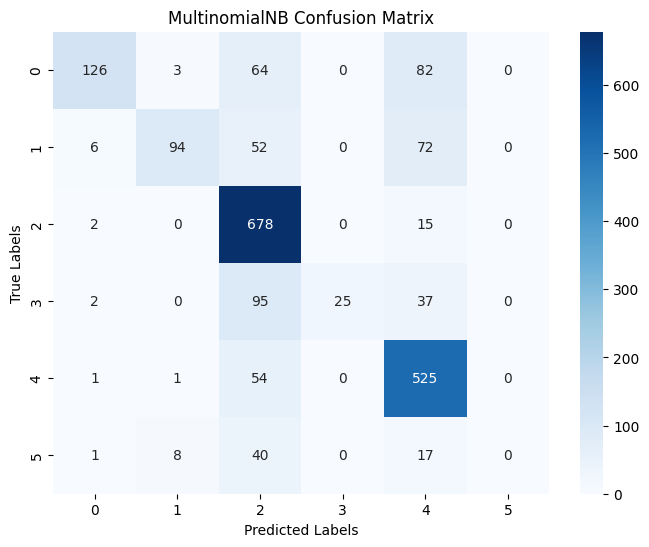


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.91      0.46      0.61       275
           1       0.89      0.42      0.57       224
           2       0.69      0.98      0.81       695
           3       1.00      0.16      0.27       159
           4       0.70      0.90      0.79       581
           5       0.00      0.00      0.00        66

    accuracy                           0.72      2000
   macro avg       0.70      0.49      0.51      2000
weighted avg       0.75      0.72      0.68      2000





d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [74]:
nb_model = MultinomialNB()

evaluate_model_performance(
    nb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.11 K-Nearest Neighbours

KNeighborsClassifier PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 83.48%
Precision: 0.8505
Recall   : 0.8348
F1 Score : 0.8349

TESTING METRICS
------------------------------
Accuracy : 72.55%
Precision: 0.7483
Recall   : 0.7255
F1 Score : 0.7257


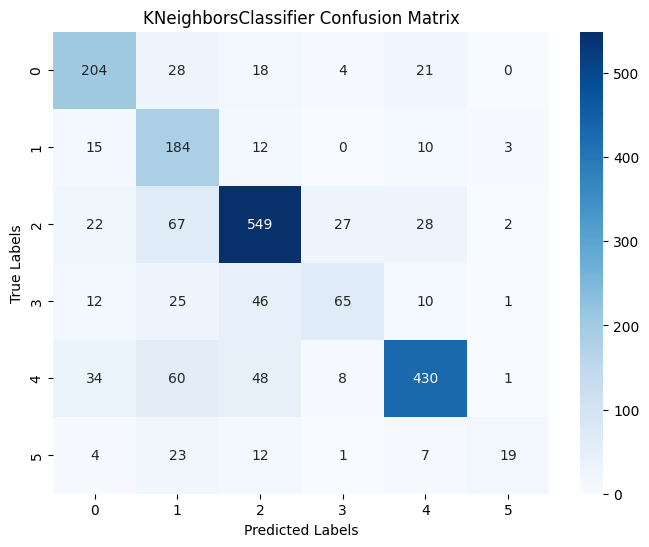


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       275
           1       0.48      0.82      0.60       224
           2       0.80      0.79      0.80       695
           3       0.62      0.41      0.49       159
           4       0.85      0.74      0.79       581
           5       0.73      0.29      0.41        66

    accuracy                           0.73      2000
   macro avg       0.70      0.63      0.64      2000
weighted avg       0.75      0.73      0.73      2000





In [75]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

evaluate_model_performance(
    knn_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.12 Extra Trees Classifier

ExtraTreesClassifier PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 99.95%
Precision: 0.9995
Recall   : 0.9995
F1 Score : 0.9995

TESTING METRICS
------------------------------
Accuracy : 86.30%
Precision: 0.8636
Recall   : 0.8630
F1 Score : 0.8630


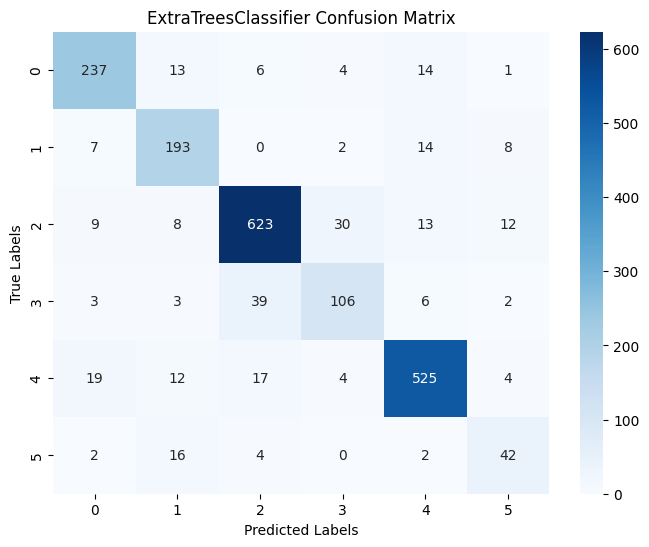


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       275
           1       0.79      0.86      0.82       224
           2       0.90      0.90      0.90       695
           3       0.73      0.67      0.70       159
           4       0.91      0.90      0.91       581
           5       0.61      0.64      0.62        66

    accuracy                           0.86      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.86      0.86      0.86      2000





In [76]:
et_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42
)

evaluate_model_performance(
    et_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.13 AdaBoost Classifier

d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


AdaBoostClassifier PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 34.35%
Precision: 0.2735
Recall   : 0.3435
F1 Score : 0.1892

TESTING METRICS
------------------------------
Accuracy : 35.35%
Precision: 0.2852
Recall   : 0.3535
F1 Score : 0.1969


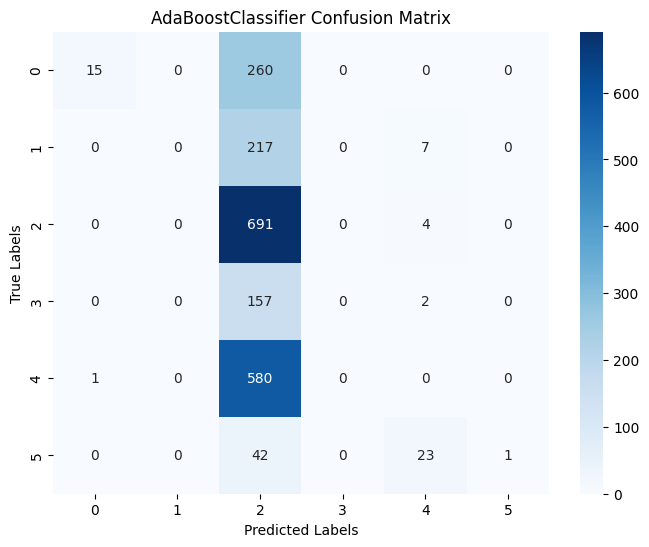


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.94      0.05      0.10       275
           1       0.00      0.00      0.00       224
           2       0.35      0.99      0.52       695
           3       0.00      0.00      0.00       159
           4       0.00      0.00      0.00       581
           5       1.00      0.02      0.03        66

    accuracy                           0.35      2000
   macro avg       0.38      0.18      0.11      2000
weighted avg       0.29      0.35      0.20      2000





d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [77]:
adb_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

evaluate_model_performance(
    adb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.14 MLP Classifier (Sklearn)

MLPClassifier PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 99.95%
Precision: 0.9995
Recall   : 0.9995
F1 Score : 0.9995

TESTING METRICS
------------------------------
Accuracy : 80.25%
Precision: 0.8036
Recall   : 0.8025
F1 Score : 0.8028


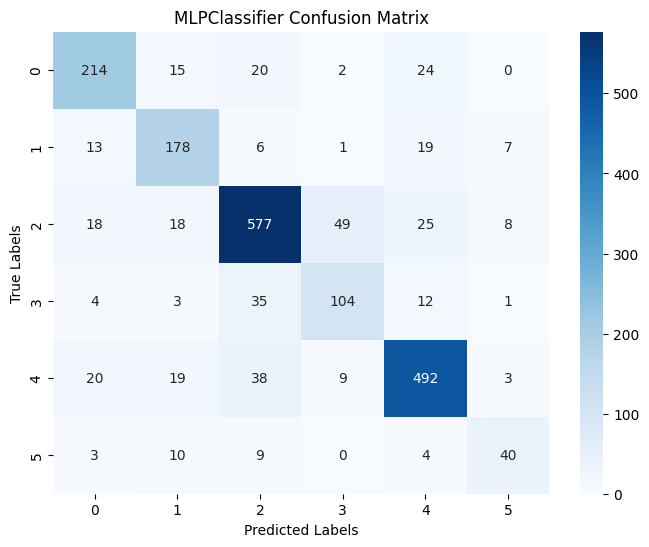


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.79      0.78      0.78       275
           1       0.73      0.79      0.76       224
           2       0.84      0.83      0.84       695
           3       0.63      0.65      0.64       159
           4       0.85      0.85      0.85       581
           5       0.68      0.61      0.64        66

    accuracy                           0.80      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.80      0.80      0.80      2000





In [78]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

evaluate_model_performance(
    mlp_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.15 XGBoost Classifier

XGBClassifier PERFORMANCE

TRAINING METRICS
------------------------------
Accuracy : 94.59%
Precision: 0.9462
Recall   : 0.9459
F1 Score : 0.9459

TESTING METRICS
------------------------------
Accuracy : 85.65%
Precision: 0.8593
Recall   : 0.8565
F1 Score : 0.8570


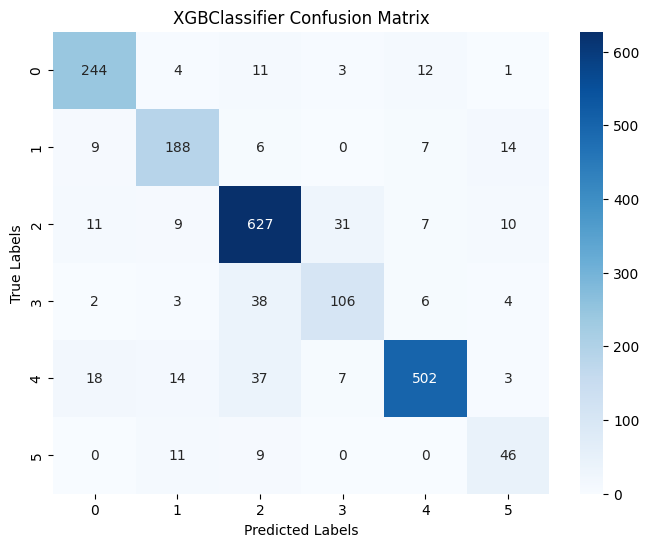


CLASSIFICATION REPORT
------------------------------
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       275
           1       0.82      0.84      0.83       224
           2       0.86      0.90      0.88       695
           3       0.72      0.67      0.69       159
           4       0.94      0.86      0.90       581
           5       0.59      0.70      0.64        66

    accuracy                           0.86      2000
   macro avg       0.80      0.81      0.80      2000
weighted avg       0.86      0.86      0.86      2000





In [79]:
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=6,
    eval_metric='mlogloss',
    random_state=42
)

evaluate_model_performance(
    xgb_model,
    X_train,
    y_train,
    X_test,
    y_test
)

### 7.16 Classical ML — Consolidated Results Table

> **Best model:** ExtraTreesClassifier at **86.30% test accuracy**

In [80]:
results_df = pd.DataFrame({

    "Model": model_names,

    "Train Accuracy": training_accuracy_scores,
    "Test Accuracy": testing_accuracy_scores,

    "Train Precision": training_precision_scores,
    "Test Precision": testing_precision_scores,

    "Train Recall": training_recall_scores,
    "Test Recall": testing_recall_scores,

    "Train F1": training_f1_scores,
    "Test F1": testing_f1_scores

})

results_df.sort_values(by="Test Accuracy")

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1
7,AdaBoostClassifier,34.351863,35.35,0.273451,0.285236,0.343519,0.3535,0.189151,0.196934
4,MultinomialNB,78.410089,72.40,0.827856,0.747938,0.784101,0.7240,0.752357,0.679639
5,KNeighborsClassifier,83.479734,72.55,0.850527,0.748347,0.834797,0.7255,0.834850,0.725675
2,DecisionTreeClassifier,99.949805,78.75,0.999499,0.803799,0.999498,0.7875,0.999498,0.792529
8,MLPClassifier,99.949805,80.25,0.999498,0.803550,0.999498,0.8025,0.999498,0.802777
3,RandomForestClassifier,99.949805,83.70,0.999499,0.848818,0.999498,0.8370,0.999498,0.840440
0,LogisticRegression,91.228510,84.60,0.922928,0.865483,0.912285,0.8460,0.914068,0.851143
9,XGBClassifier,94.591542,85.65,0.946178,0.859250,0.945915,0.8565,0.945943,0.856970
1,LinearSVC,96.360898,85.85,0.964597,0.864864,0.963609,0.8585,0.963767,0.860709
6,ExtraTreesClassifier,99.949805,86.30,0.999499,0.863593,0.999498,0.8630,0.999498,0.862983


### 7.17 Hyperparameter Tuning — GridSearchCV (5-Fold CV)

> Running grid search for all major classifiers to find optimal hyperparameters.

In [83]:
# Hyper parameter Tuning
# MODELS + PARAMETER GRIDS
models = {

    "LogisticRegression": {

        "model": LogisticRegression(),

        "params": {

            "C": [0.1, 1, 10]
        }
    },

    "LinearSVC": {

        "model": LinearSVC(),

        "params": {

            "C": [0.1, 1, 10]
        }
    },

    "DecisionTreeClassifier": {

        "model": DecisionTreeClassifier(),

        "params": {

            "max_depth": [5, 10, 20],

            "min_samples_split": [2, 5]
        }
    },

    "RandomForestClassifier": {

        "model": RandomForestClassifier(),

        "params": {

            "n_estimators": [50, 100],

            "max_depth": [10, 20]
        }
    },

    "MultinomialNB": {

        "model": MultinomialNB(),

        "params": {

            "alpha": [0.1, 0.5, 1.0]
        }
    },

    "KNeighborsClassifier": {

        "model": KNeighborsClassifier(),

        "params": {

            "n_neighbors": [3, 5, 7]
        }
    },

    "ExtraTreesClassifier": {

        "model": ExtraTreesClassifier(),

        "params": {

            "n_estimators": [50, 100],

            "max_depth": [10, 20]
        }
    },

    "AdaBoostClassifier": {

        "model": AdaBoostClassifier(),

        "params": {

            "n_estimators": [50, 100],

            "learning_rate": [0.5, 1.0]
        }
    },

    "MLPClassifier": {

        "model": MLPClassifier(max_iter=300),

        "params": {

            "hidden_layer_sizes": [
                (100,),
                (100, 50)
            ],

            "activation": [
                "relu",
                "tanh"
            ]
        }
    },

    "XGBClassifier": {

        "model": XGBClassifier(
            eval_metric='mlogloss'
        ),

        "params": {

            "n_estimators": [50, 100],

            "max_depth": [3, 5],

            "learning_rate": [0.05, 0.1]
        }
    }
}

# RESULTS LIST

tuned_results = []

# LOOP THROUGH MODELS
for model_name, model_info in models.items():

    print("=" * 60)
    print(f"RUNNING GRID SEARCH FOR: {model_name}")
    print("=" * 60)

    # GRID SEARCH

    grid_search = GridSearchCV(

        estimator=model_info["model"],

        param_grid=model_info["params"],

        cv=5,

        scoring='f1_weighted',

        n_jobs=-1
    )

    # TRAIN

    grid_search.fit(X_train, y_train)

    # BEST MODEL

    best_model = grid_search.best_estimator_

    # PREDICTIONS

    y_train_pred = best_model.predict(X_train)

    y_test_pred = best_model.predict(X_test)

    # METRICS

    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )

    test_precision = precision_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    test_recall = recall_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    test_f1 = f1_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    # STORE RESULTS

    tuned_results.append({

        "Model": model_name,

        "Best Parameters": grid_search.best_params_,

        "CV Score": grid_search.best_score_,

        "Train Accuracy": train_accuracy,

        "Test Accuracy": test_accuracy,

        "Precision": test_precision,

        "Recall": test_recall,

        "F1 Score": test_f1
    })

# =========================================
# RESULTS DATAFRAME
# =========================================

tuned_results_df = pd.DataFrame(tuned_results)

# SORT RESULTS

tuned_results_df = tuned_results_df.sort_values(
    by='F1 Score',
    ascending=False
)

# DISPLAY RESULTS

tuned_results_df

RUNNING GRID SEARCH FOR: LogisticRegression


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RUNNING GRID SEARCH FOR: LinearSVC
RUNNING GRID SEARCH FOR: DecisionTreeClassifier
RUNNING GRID SEARCH FOR: RandomForestClassifier
RUNNING GRID SEARCH FOR: MultinomialNB
RUNNING GRID SEARCH FOR: KNeighborsClassifier
RUNNING GRID SEARCH FOR: ExtraTreesClassifier


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


RUNNING GRID SEARCH FOR: AdaBoostClassifier


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


RUNNING GRID SEARCH FOR: MLPClassifier


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:788: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


RUNNING GRID SEARCH FOR: XGBClassifier


,Model,Best Parameters,CV Score,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
1,LinearSVC,{'C': 1},0.854028,0.966746,0.8600,0.859050,0.8600,0.859186
0,LogisticRegression,{'C': 10},0.844612,0.977036,0.8510,0.849286,0.8510,0.849726
9,XGBClassifier,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",0.796547,0.860334,0.8125,0.830372,0.8125,0.812854
8,MLPClassifier,"{'activation': 'relu', 'hidden_layer_sizes': (...",0.795299,0.999498,0.8070,0.807733,0.8070,0.807089
5,KNeighborsClassifier,{'n_neighbors': 7},0.751512,0.841574,0.7595,0.769497,0.7595,0.755832
4,MultinomialNB,{'alpha': 0.1},0.730456,0.896976,0.7550,0.764152,0.7550,0.734357
3,RandomForestClassifier,"{'max_depth': 20, 'n_estimators': 100}",0.432118,0.524093,0.4880,0.754228,0.4880,0.415636
6,ExtraTreesClassifier,"{'max_depth': 20, 'n_estimators': 50}",0.373846,0.482934,0.4730,0.694591,0.4730,0.373188
2,DecisionTreeClassifier,"{'max_depth': 20, 'min_samples_split': 5}",0.286389,0.424018,0.4055,0.615014,0.4055,0.292576
7,AdaBoostClassifier,"{'learning_rate': 1.0, 'n_estimators': 100}",0.189757,0.343519,0.3535,0.285236,0.3535,0.196934


---

## 🔁 Phase 2: Deep Learning — RNN / LSTM / GRU (Keras)

> We switch to a lighter preprocessing pipeline (no stemming) to preserve context for sequence models, then experiment with vanilla and bidirectional RNN architectures.

### Deep Learning

### 8.1 Text Preprocessing for Deep Learning Pipeline

In [84]:
# NLP TEXT PREPROCESSING FOR DEEP LEARNING PIPELINE

# CHAT WORD DICTIONARY
chat_words = {

    "u": "you",
    "ur": "your",
    "idk": "i do not know",
    "omg": "oh my god",
    "btw": "by the way",
    "lol": "laugh",
    "thx": "thanks",
    "pls": "please"

}

# CHAT WORD CONVERSION FUNCTION
def chat_conversion(text):

    new_text = []

    for word in text.split():

        if word in chat_words:
            new_text.append(chat_words[word])

        else:
            new_text.append(word)

    return " ".join(new_text)



# MAIN CLEANING FUNCTION
def clean_text_dl(text):

    text = str(text)

    # LOWERCASE
    text = text.lower()

    # REMOVE HTML
    text = re.sub(r'<.*?>', '', text)

    # REMOVE URLS
    text = re.sub(
        r'https?://\S+|www\.\S+',
        '',
        text
    )

    # CHAT WORDS
    text = chat_conversion(text)

    # HANDLE EMOJIS
    text = emoji.demojize(text)

    text = text.replace(":", " ")

    # REMOVE EXTRA SPACES
    text = re.sub(
        r'\s+',
        ' ',
        text
    ).strip()

    return text

# APPLY PREPROCESSING
dl_train = train_df.copy()
dl_test = test_df.copy()
dl_val = val_df.copy()

dl_train["clean_text"] = dl_train["text"].apply(
    clean_text_dl
)

dl_test["clean_text"] = dl_test["text"].apply(
    clean_text_dl
)

dl_val["clean_text"] = dl_val["text"].apply(
    clean_text_dl
)

# CHECK RESULTS
dl_train[
    ["text", "clean_text"]
].head()

,text,clean_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy


### 8.2 Label Encoding for DL Pipeline

In [85]:
# Label Encoding

encoder = LabelEncoder()

y_train = encoder.fit_transform(
    dl_train["emotion"]
)

y_test = encoder.transform(
    dl_test["emotion"]
)

y_val = encoder.transform(
    dl_val["emotion"]
)

### 8.3 Keras Tokenizer — Build Vocabulary

In [86]:
# VOCAB SIZE
MAX_WORDS = 20000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

# FIT TOKENIZER
tokenizer.fit_on_texts(
    dl_train["clean_text"]
)

### 8.4 Text-to-Sequence Conversion

In [87]:
# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(
    dl_train["clean_text"]
)

X_test_seq = tokenizer.texts_to_sequences(
    dl_test["clean_text"]
)

X_val_seq = tokenizer.texts_to_sequences(
    dl_val["clean_text"]
)

### 8.5 Pad Sequences (maxlen = 100)

In [88]:
# Padding

MAX_LEN = 100

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

### 8.6 Verify Padded Shape

In [89]:
print(X_train_pad.shape)
print(X_test_pad.shape)
print(X_val_pad.shape)

(15938, 100)
(2000, 100)
(2000, 100)


### 8.7 DL Evaluation Helper Function

In [94]:
# RESULTS LIST

results = []

# DL EVALUATION FUNCTION
def evaluate_dl_model(

    model,
    model_name,

    x_train,
    y_train,

    x_test,
    y_test,

    x_val,
    y_val,

    epochs=10,
    batch_size=32
):

    # EARLY STOPPING

    early_stop = EarlyStopping(

        monitor='val_loss',

        patience=3,

        restore_best_weights=True
    )

    # TRAIN MODEL

    history = model.fit(

        x_train,
        y_train,

        validation_data=(x_val, y_val),

        epochs=epochs,

        batch_size=batch_size,

        callbacks=[early_stop],

        verbose=1
    )

    # PREDICTIONS

    y_pred_prob = model.predict(x_test)

    y_pred = np.argmax(
        y_pred_prob,
        axis=1
    )

    # METRICS

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    # STORE RESULTS

    results.append({

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1
    })

    print("=" * 60)
    print(f"{model_name} COMPLETED")
    print("=" * 60)


### 8.8 Common Hyperparameters

In [95]:
# COMMON VARIABLES
VOCAB_SIZE = MAX_WORDS

EMBEDDING_DIM = 128

MAX_LENGTH = MAX_LEN

NUM_CLASSES = len(np.unique(y_train))

### 8.9 Model 1 — Simple RNN

> Architecture: Embedding → SimpleRNN(64) → Dense(6, softmax)

In [96]:
# SIMPLE RNN

simple_rnn_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    SimpleRNN(64),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

simple_rnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    simple_rnn_model,

    "Simple RNN",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.3161 - loss: 1.5843 - val_accuracy: 0.2750 - val_loss: 1.5878
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.3273 - loss: 1.5794 - val_accuracy: 0.3520 - val_loss: 1.5827
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.3317 - loss: 1.5779 - val_accuracy: 0.2750 - val_loss: 1.5878
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.3301 - loss: 1.5762 - val_accuracy: 0.3520 - val_loss: 1.5861
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.3224 - loss: 1.5938 - val_accuracy: 0.2930 - val_loss: 1.6036
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Simple RNN COMPLETED


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 8.10 Model 2 — LSTM

> Architecture: Embedding → LSTM(64) → Dense(6, softmax)

In [97]:
# LSTM

lstm_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    LSTM(64),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

lstm_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    lstm_model,

    "LSTM",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.3278 - loss: 1.5822 - val_accuracy: 0.3520 - val_loss: 1.5806
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.3345 - loss: 1.5764 - val_accuracy: 0.3520 - val_loss: 1.5820
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.3281 - loss: 1.5756 - val_accuracy: 0.3520 - val_loss: 1.5804
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.3331 - loss: 1.5759 - val_accuracy: 0.3520 - val_loss: 1.5793
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3328 - loss: 1.5748 - val_accuracy: 0.3520 - val_loss: 1.5808
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.3350 - loss: 1.5752 - val_accuracy: 0.3520 - val_loss: 1.5793
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.3329 - loss: 1.5752 - val_accuracy: 0.3520 - val_loss: 1.5828
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
LSTM COMPLETED


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 8.11 Model 3 — GRU

> Architecture: Embedding → GRU(64) → Dense(6, softmax)

In [98]:
# GRU

gru_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    GRU(64),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

gru_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    gru_model,

    "GRU",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 21s 39ms/step - accuracy: 0.3308 - loss: 1.5803 - val_accuracy: 0.3520 - val_loss: 1.5842
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.3338 - loss: 1.5766 - val_accuracy: 0.3520 - val_loss: 1.5826
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.3353 - loss: 1.5763 - val_accuracy: 0.3520 - val_loss: 1.5823
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.3353 - loss: 1.5759 - val_accuracy: 0.3520 - val_loss: 1.5853
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 49s 75ms/step - accuracy: 0.3353 - loss: 1.5765 - val_accuracy: 0.3520 - val_loss: 1.5846
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.3353 - loss: 1.5761 - val_accuracy: 0.3520 - val_loss: 1.5808
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.3342 - loss: 1.5751 - val_accuracy: 0.3520 - val_loss: 1.5877
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.3353 - loss: 1.5751 - val_accurac

d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 8.12 Model 4 — Bidirectional Simple RNN

> Architecture: Embedding → Bidirectional(SimpleRNN(64)) → Dense(6, softmax)

In [99]:
# BIDIRECTIONAL SIMPLE RNN

bi_rnn_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    Bidirectional(
        SimpleRNN(64)
    ),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

bi_rnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    bi_rnn_model,

    "Bidirectional Simple RNN",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.4538 - loss: 1.4281 - val_accuracy: 0.6505 - val_loss: 1.0498
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.7809 - loss: 0.6610 - val_accuracy: 0.7805 - val_loss: 0.6597
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9077 - loss: 0.2953 - val_accuracy: 0.7470 - val_loss: 0.8044
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9662 - loss: 0.1136 - val_accuracy: 0.8070 - val_loss: 0.6427
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9832 - loss: 0.0622 - val_accuracy: 0.8330 - val_loss: 0.6005
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9900 - loss: 0.0384 - val_accuracy: 0.7670 - val_loss: 0.9440
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9863 - loss: 0.0464 - val_accuracy: 0.7140 - val_loss: 1.1094
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.9852 - loss: 0.0480 - val_accurac

### 8.13 Model 5 — Bidirectional LSTM

> Architecture: Embedding → Bidirectional(LSTM(64)) → Dense(6, softmax)

In [100]:
# BIDIRECTIONAL LSTM

bi_lstm_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

bi_lstm_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    bi_lstm_model,

    "Bidirectional LSTM",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.6203 - loss: 1.0157 - val_accuracy: 0.8115 - val_loss: 0.5401
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9112 - loss: 0.2648 - val_accuracy: 0.9000 - val_loss: 0.2796
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9573 - loss: 0.1200 - val_accuracy: 0.9070 - val_loss: 0.2746
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9738 - loss: 0.0787 - val_accuracy: 0.9035 - val_loss: 0.3104
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9814 - loss: 0.0536 - val_accuracy: 0.9100 - val_loss: 0.3033
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.9860 - loss: 0.0429 - val_accuracy: 0.9110 - val_loss: 0.3378
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Bidirectional LSTM COMPLETED


### 8.14 Model 6 — Bidirectional GRU ⭐

> Architecture: Embedding → Bidirectional(GRU(64)) → Dense(6, softmax)

> **Best DL model** — achieves 91.60% test accuracy.

In [101]:
# BIDIRECTIONAL GRU

bi_gru_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    Bidirectional(
        GRU(64)
    ),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

bi_gru_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    bi_gru_model,

    "Bidirectional GRU",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.6214 - loss: 1.0079 - val_accuracy: 0.8455 - val_loss: 0.4562
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.9046 - loss: 0.2743 - val_accuracy: 0.9115 - val_loss: 0.2629
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9541 - loss: 0.1247 - val_accuracy: 0.9175 - val_loss: 0.2448
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9757 - loss: 0.0688 - val_accuracy: 0.9080 - val_loss: 0.2991
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9815 - loss: 0.0510 - val_accuracy: 0.9130 - val_loss: 0.3155
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 23s 46ms/step - accuracy: 0.9871 - loss: 0.0325 - val_accuracy: 0.9050 - val_loss: 0.3403
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
Bidirectional GRU COMPLETED


### 8.15 Model 7 — Stacked Simple RNN

> Architecture: Embedding → SimpleRNN(64, return_sequences=True) → SimpleRNN(32) → Dense(6)

In [102]:
# STACKED SIMPLE RNN

stacked_rnn_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    SimpleRNN(
        64,
        return_sequences=True
    ),

    SimpleRNN(32),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

stacked_rnn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    stacked_rnn_model,

    "Stacked Simple RNN",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.3298 - loss: 1.5840 - val_accuracy: 0.3520 - val_loss: 1.5891
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.3292 - loss: 1.5817 - val_accuracy: 0.3520 - val_loss: 1.5836
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.3308 - loss: 1.5781 - val_accuracy: 0.3520 - val_loss: 1.5845
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.3296 - loss: 1.5770 - val_accuracy: 0.3520 - val_loss: 1.5889
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.3293 - loss: 1.5772 - val_accuracy: 0.3520 - val_loss: 1.5819
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.3283 - loss: 1.5768 - val_accuracy: 0.3520 - val_loss: 1.5847
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.3270 - loss: 1.5776 - val_accuracy: 0.3520 - val_loss: 1.5811
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.3335 - loss: 1.5760 - val_accurac

d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 8.16 Model 8 — Stacked LSTM

> Architecture: Embedding → LSTM(64, return_sequences=True) → LSTM(32) → Dense(6)

In [103]:
# STACKED LSTM

stacked_lstm_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    LSTM(
        64,
        return_sequences=True
    ),

    LSTM(32),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

stacked_lstm_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    stacked_lstm_model,

    "Stacked LSTM",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.3259 - loss: 1.5796 - val_accuracy: 0.3520 - val_loss: 1.5816
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.3353 - loss: 1.5756 - val_accuracy: 0.3520 - val_loss: 1.5802
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.3310 - loss: 1.5755 - val_accuracy: 0.3520 - val_loss: 1.5798
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.3337 - loss: 1.5752 - val_accuracy: 0.3520 - val_loss: 1.5805
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.3353 - loss: 1.5752 - val_accuracy: 0.3520 - val_loss: 1.5812
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.3334 - loss: 1.5751 - val_accuracy: 0.3520 - val_loss: 1.5848
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
Stacked LSTM COMPLETED


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 8.17 Model 9 — Stacked GRU

> Architecture: Embedding → GRU(64, return_sequences=True) → GRU(32) → Dense(6)

In [104]:
# STACKED GRU

stacked_gru_model = Sequential([

    Embedding(
        VOCAB_SIZE,
        EMBEDDING_DIM,
        input_length=MAX_LENGTH
    ),

    GRU(
        64,
        return_sequences=True
    ),

    GRU(32),

    Dense(
        NUM_CLASSES,
        activation='softmax'
    )
])

stacked_gru_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

evaluate_dl_model(

    stacked_gru_model,

    "Stacked GRU",

    X_train_pad,
    y_train,

    X_test_pad,
    y_test,

    X_val_pad,
    y_val
)

Epoch 1/10


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


499/499 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.3286 - loss: 1.5815 - val_accuracy: 0.3520 - val_loss: 1.5838
Epoch 2/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.3303 - loss: 1.5764 - val_accuracy: 0.3520 - val_loss: 1.5852
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.3331 - loss: 1.5772 - val_accuracy: 0.3520 - val_loss: 1.5818
Epoch 4/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.3340 - loss: 1.5765 - val_accuracy: 0.2750 - val_loss: 1.5905
Epoch 5/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.3324 - loss: 1.5756 - val_accuracy: 0.3520 - val_loss: 1.5803
Epoch 6/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.3339 - loss: 1.5759 - val_accuracy: 0.3520 - val_loss: 1.5814
Epoch 7/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 37s 50ms/step - accuracy: 0.3353 - loss: 1.5754 - val_accuracy: 0.3520 - val_loss: 1.5815
Epoch 8/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.3353 - loss: 1.5754 - val_accurac

d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 8.18 Deep Learning — Consolidated Results Table

| Model | Test Accuracy | F1 Score |
|---|---|---|
| **Bidirectional GRU** | **91.60%** | **0.916** |
| Bidirectional LSTM | 90.10% | 0.902 |
| Bidirectional Simple RNN | 83.15% | 0.828 |
| Simple RNN / LSTM / GRU / Stacked variants | ~34.75% | ~0.179 |


In [105]:
# FINAL RESULTS TABLE

dl_results_df = pd.DataFrame(results)

dl_results_df = dl_results_df.sort_values(

    by='F1 Score',

    ascending=False
)

dl_results_df

,Model,Accuracy,Precision,Recall,F1 Score
5,Bidirectional GRU,0.9160,0.916429,0.9160,0.916028
4,Bidirectional LSTM,0.9010,0.904809,0.9010,0.902236
3,Bidirectional Simple RNN,0.8315,0.828551,0.8315,0.828233
0,Simple RNN,0.3475,0.120756,0.3475,0.179230
2,GRU,0.3475,0.120756,0.3475,0.179230
1,LSTM,0.3475,0.120756,0.3475,0.179230
6,Stacked Simple RNN,0.3475,0.120756,0.3475,0.179230
7,Stacked LSTM,0.3475,0.120756,0.3475,0.179230
8,Stacked GRU,0.3475,0.120756,0.3475,0.179230


### 8.19 Save Best DL Model

In [134]:
bi_gru_model.save("model.keras")

---

## 🤗 Phase 3: Transformer Fine-Tuning (DistilBERT)

> Fine-tune `distilbert-base-uncased` for 3 epochs on the full training set using the Hugging Face `Trainer` API. This is the final and best-performing model.

### Pretrained Models

### 9.1 Inspect Training DataFrame

In [ ]:
train_df

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


### 9.2 Minimal Text Cleaning for Transformer (URL removal only)

In [73]:
# Cleaning for pretrained models
def clean_text(text):

    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

### 9.3 Map Emotion Labels to Integer IDs

In [74]:
# convert labels to id

label2id = {
    "joy":0,
    "sadness":1,
    "anger":2,
    "fear":3,
    "love":4,
    "surprise":5
}

train_df["label"] = train_df["emotion"].map(label2id)

val_df["label"] = val_df["emotion"].map(label2id)

test_df["label"] = test_df["emotion"].map(label2id)

### 9.4 Apply Cleaning to All Splits

In [75]:
train_df["pretrained_text"] = train_df["text"].apply(clean_text)

val_df["pretrained_text"] = val_df["text"].apply(clean_text)

test_df["pretrained_text"] = test_df["text"].apply(clean_text)

### 9.5 Load DistilBERT Tokenizer

In [76]:
# Load Tokenizer
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

### 9.6 Tokenizer Function (max_length = 64)

In [77]:
# Tokenizer function
def tokenize_function(example):

    return tokenizer(
        example["pretrained_text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

### 9.7 Convert DataFrames to HuggingFace Datasets

In [78]:
# Converting pandas Dataframe to Datasets
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)

val_dataset = Dataset.from_pandas(val_df)

test_dataset = Dataset.from_pandas(test_df)

### 9.8 Apply Tokenization via `.map()`

In [79]:
# Apply Tokenization
train_dataset = train_dataset.map(tokenize_function)

val_dataset = val_dataset.map(tokenize_function)

test_dataset = test_dataset.map(tokenize_function)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 4570.55 examples/s]


### 9.9 Remove Unused Columns

In [80]:
train_dataset = train_dataset.remove_columns(
    ["text", "pretrained_text", "emotion"]
)

val_dataset = val_dataset.remove_columns(
    ["text", "pretrained_text", "emotion"]
)

test_dataset = test_dataset.remove_columns(
    ["text", "pretrained_text", "emotion"]
)

### 9.10 Rename Label Column to `labels`

In [81]:
# Rename Label columns
train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "label",
    "labels"
)

### 9.11 Set Dataset Format to PyTorch Tensors

In [82]:
# Set Dataset format
train_dataset.set_format("torch")

val_dataset.set_format("torch")

test_dataset.set_format("torch")

### 9.12 Load Pretrained DistilBERT with Classification Head

In [83]:
# Load pretrained Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3562.07it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### 9.13 Define `compute_metrics` Callback

In [84]:
# Creating Metrics function
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

### 9.14 Configure Training Arguments

In [86]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="no",  # Keep this to avoid serialization error
    logging_dir="./logs",
    load_best_model_at_end=False  # Change this to False
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


### 9.15 Instantiate the Trainer

In [87]:
# trainer
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics
)

### 9.16 Fine-Tune the Model *(~76 min on CPU, 3 epochs)*

> **Training progress:**
> | Epoch | Train Loss | Val Loss | Val Accuracy | Val F1 |
> |---|---|---|---|---|
> | 1 | 0.5468 | 0.1512 | 93.95% | 0.9387 |
> | 2 | 0.1478 | 0.1529 | 93.70% | 0.9362 |
> | 3 | 0.0856 | 0.1621 | 93.85% | 0.9384 |


In [88]:
# Train Model
trainer.train()

d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.546798,0.151193,0.939500,0.940102,0.939500,0.938652
2,0.147784,0.152877,0.937000,0.938876,0.937000,0.936210
3,0.085644,0.162067,0.938500,0.938732,0.938500,0.938365


d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=2991, training_loss=0.20150901975539248, metrics={'train_runtime': 4596.2795, 'train_samples_per_second': 10.403, 'train_steps_per_second': 0.651, 'total_flos': 791781002049024.0, 'train_loss': 0.20150901975539248, 'epoch': 3.0})

### 9.17 Evaluate on Test Set

> **Expected results:**
> - Test Accuracy: **93.35%**
> - Test F1: **0.9332**
> - Test Loss: 0.1888

In [89]:
trainer.evaluate(test_dataset)

d:\NLP and RNN\emotion_detection_from_text\myenv\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.085644,0.188848,3,0.933500,0.934209,0.933500,0.933203


{'eval_loss': 0.1888483464717865,
 'eval_accuracy': 0.9335,
 'eval_precision': 0.9342088717264769,
 'eval_recall': 0.9335,
 'eval_f1': 0.933203386570986}

### 9.18 Sample Inference

> Quick sanity-check: run a single sentence through the fine-tuned model.

In [94]:
text = "I was shocked and angry after hearing the news"

inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)

outputs = model(**inputs)

prediction = outputs.logits.argmax(dim=1).item()

print(prediction)

id2label = {
    0:"joy",
    1:"sadness",
    2:"anger",
    3:"fear",
    4:"love",
    5:"surprise"
}

print(id2label[prediction])

5
surprise


### 9.19 Save Fine-Tuned Model & Tokenizer

In [96]:
model.save_pretrained("emotion_model")
tokenizer.save_pretrained("emotion_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.94it/s]


('emotion_model\\tokenizer_config.json', 'emotion_model\\tokenizer.json')

---

## 📊 Final Model Comparison

| Phase | Best Model | Test Accuracy | Test F1 |
|---|---|---|---|
| Classical ML | ExtraTreesClassifier | 86.30% | 0.863 |
| Deep Learning | Bidirectional GRU | 91.60% | 0.916 |
| **Transformer** | **DistilBERT (fine-tuned)** | **93.35%** | **0.933** |

### Key Takeaways

- **Bidirectional wrappers** are essential for RNN-family models on this dataset — unidirectional variants collapsed to ~34.75% (near-random) accuracy.
- **TF-IDF + ExtraTrees** is a strong 86.3% baseline — fast and practical when inference latency matters.
- **DistilBERT** achieves the best overall performance (93.35% test accuracy), outperforming the best DL model by **+1.75%** and the best classical ML model by **+7.05%**.
- **Class imbalance** (surprise ~3.2%, fear ~12.2%) remains a challenge — focal loss or oversampling may improve minority-class F1 in future iterations.
- **Preprocessing must match the model**: aggressive stemming helps TF-IDF but degrades transformer performance.
